In [2]:
import sys
sys.path.append('..')
from sqlalchemy import create_engine, text
import os

import geopandas as gpd
import pandas as pd
from geoalchemy2 import Geometry
import matplotlib.pyplot as plt

import dataframe_image as dfi
from reportlab.lib.pagesizes import letter, landscape
from reportlab.pdfgen import canvas
from reportlab.lib.units import inch

from config import RUTA_UNIDAD_ONE_DRIVE
from config import RUTA_LOCAL_ONE_DRIVE
from config import API_AMIGOCLOUD_TOKEN_ADM
from config import POSTGRES_UTEA

POSTGRES_UTEA['DATABASE'] = 'utea_precision'

In [3]:
def obtener_engine():
    return create_engine(
        f"postgresql+psycopg2://{POSTGRES_UTEA['USER']}:{POSTGRES_UTEA['PASSWORD']}@{POSTGRES_UTEA['HOST']}:{POSTGRES_UTEA['PORT']}/{POSTGRES_UTEA['DATABASE']}"
    )

def obtener_lotes_sin_planos():
    engine = obtener_engine()
    
    # Filtramos por lineas_creadas = True y segmentos_creados = False
    query = text("""
        SELECT * FROM siembra_surcado.data_lote 
            WHERE puntos_cargados IS TRUE
            AND lineas_creadas IS TRUE
            AND segmentos_creados IS TRUE
            AND desviacion_calculada IS TRUE
            AND velocidad_calculada IS TRUE
    """)
    
    try:
        with engine.connect() as conn:
            df = pd.read_sql(
                query, 
                conn, 
                params={
                    "lineas": True, 
                    "segmentos": False
                }
            )
        return df
    except Exception as e:
        print(f"Error al obtener lista de lotes son plano: {e}")
        return None
    
def get_segmentos_lote(id_lote):
    engine = obtener_engine()
    try:
        query = f"""
            SELECT * FROM siembra_surcado.segmentos_lineas where data_lote_id = {id_lote}
        """
        gdf = gpd.read_postgis(query, engine, geom_col='geom')
        return gdf
    except Exception as e:
        print(f"❌ No se pudo obtener segmentos de lote: {e}")
        return gpd.GeoDataFrame()
    return None

In [4]:
lista_lotes_sin_plano = obtener_lotes_sin_planos()
print(len(lista_lotes_sin_plano), 'lotes sin planos')

29 lotes sin planos


In [5]:
for index, row in lista_lotes_sin_plano.iterrows():
    print(row['id'])

8
7
6
2
5
4
1
36
32
31
30
29
28
26
23
22
21
20
19
18
17
16
15
14
13
12
11
10
9


In [73]:
data_lote_id = 32
name = 'CAMBERRA'
lote = 'C4'

<Axes: >

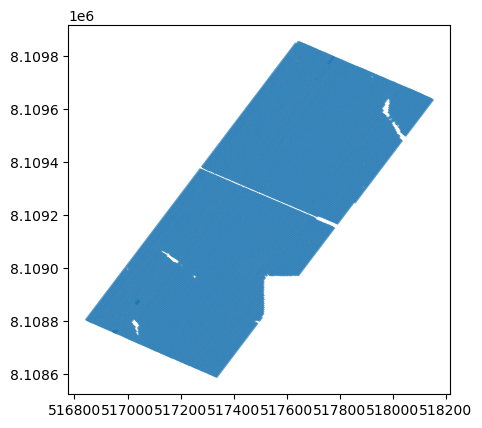

In [74]:
segmentos_lote = get_segmentos_lote(data_lote_id)
segmentos_lote.plot()

In [75]:
# USO:
exportar_a_pdf(segmentos_lote, name, lote)

PDF generado con divisiones: CAMBERRA_C4.pdf


In [44]:
# 1. Configuración de colores para paralelismo
categorias_paralelismo = {
    '1) <5 - OPTIMO': '#228B22',
    '2) 5 a 10 - ACEPTABLE': '#9ACD32',
    '3) 10 a 15 - RIESGO MODERADO': '#FFFF00',
    '4) >15 - RIESGO ALTO': '#FF0000'
}

# 1. Configuración de colores para velocidades
categoria_velocidasdes = {
    '1) 3.3 km/h': '#FF0000',      # Rojo
    '2) 4.3 km/h': '#FFB300',      # Naranja/Ámbar
    '3) 5.3 km/h': '#FFFF00',      # Amarillo
    '4) 6.3 km/h': '#92D050',      # Verde claro
    '5) 7.3 km/h': '#00B0F0',      # Celeste/Azul claro
    '6) >7.3 km/h': '#0070C0'      # Azul oscuro
}

categoria_elevacion = {
    'Bajo': '#FF0000',   # rojo
    'Medio':'#FFFF00',  # amarillo
    'Alto': '#228B22'    # Verde (Cimas/Elevación alta)
}

In [45]:
def crear_plano_paralelismo(segmentos):
    # 1. CONFIGURACIÓN DE DIMENSIONES (1000x400 px)
    ancho_px, alto_px = 1000, 400
    mi_dpi = 100 

    # Creamos la figura: 10x4 pulgadas a 100 DPI
    fig, ax = plt.subplots(figsize=(ancho_px / mi_dpi, alto_px / mi_dpi))

    # 2. CALCULAR EL MARCO (Zoom y centrado para 2.5:1)
    minx, miny, maxx, maxy = segmentos.total_bounds
    centro_x = (minx + maxx) / 2
    centro_y = (miny + maxy) / 2
    ancho_lote = maxx - minx
    alto_lote = maxy - miny

    relacion_aspecto = ancho_px / alto_px 
    # Aumentamos ligeramente a 1.2 para dar espacio al título arriba
    rango_visual = max(ancho_lote, alto_lote * relacion_aspecto) * 1.2
    
    # 3. GRAFICAR
    for categoria, data in segmentos.groupby('categoria_variacion'):
        color = categorias_paralelismo.get(categoria, 'black')
        data.plot(ax=ax, color=color, linewidth=1.5)

    # 4. FORZAR ENCUADRE CENTRADO PROPORCIONAL
    ax.set_xlim(centro_x - rango_visual / 2, centro_x + rango_visual / 2)
    ax.set_ylim(centro_y - (rango_visual / relacion_aspecto) / 2, 
                centro_y + (rango_visual / relacion_aspecto) / 2)

    # 5. CONFIGURACIÓN ESTÉTICA Y TÍTULO
    ax.set_aspect('equal') 
    ax.axis('off')

    # 6. GUARDADO EXACTO
    plt.subplots_adjust(left=0, right=1, top=1, bottom=0)
    temp_plano_paralelismo = "temp_plano_paralelismo.png"
    plt.savefig(temp_plano_paralelismo, dpi=mi_dpi, bbox_inches=None)
    # Opcional: Cerrar la figura para liberar memoria en procesos largos
    plt.close(fig)
    return temp_plano_paralelismo
    #plt.show()

In [46]:
crear_plano_paralelismo(segmentos_lote)

'temp_plano_paralelismo.png'

In [10]:
def crear_plano_velocidad(segmentos):
    # 1. CONFIGURACIÓN DE DIMENSIONES (1000x400 px)
    ancho_px, alto_px = 1000, 400
    mi_dpi = 100 

    # Creamos la figura: 10x4 pulgadas a 100 DPI
    fig, ax = plt.subplots(figsize=(ancho_px / mi_dpi, alto_px / mi_dpi))

    # 2. CALCULAR EL MARCO (Zoom y centrado para 2.5:1)
    minx, miny, maxx, maxy = segmentos.total_bounds
    centro_x = (minx + maxx) / 2
    centro_y = (miny + maxy) / 2
    ancho_lote = maxx - minx
    alto_lote = maxy - miny

    relacion_aspecto = ancho_px / alto_px 
    # Aumentamos ligeramente a 1.2 para dar espacio al título arriba
    rango_visual = max(ancho_lote, alto_lote * relacion_aspecto) * 1.2
    
    # 3. GRAFICAR
    for categoria, data in segmentos.groupby('categoria_vehiclspee'):
        color = categoria_velocidasdes.get(categoria, 'black')
        data.plot(ax=ax, color=color, linewidth=1.5)

    # 4. FORZAR ENCUADRE CENTRADO PROPORCIONAL
    ax.set_xlim(centro_x - rango_visual / 2, centro_x + rango_visual / 2)
    ax.set_ylim(centro_y - (rango_visual / relacion_aspecto) / 2, 
                centro_y + (rango_visual / relacion_aspecto) / 2)

    # 5. CONFIGURACIÓN ESTÉTICA Y TÍTULO
    ax.set_aspect('equal') 
    ax.axis('off')

    # 6. GUARDADO EXACTO
    plt.subplots_adjust(left=0, right=1, top=1, bottom=0)
    temp_plano_velocidad = "temp_plano_velocidad.png"
    plt.savefig(temp_plano_velocidad, dpi=mi_dpi, bbox_inches=None)
    # Opcional: Cerrar la figura para liberar memoria en procesos largos
    plt.close(fig)
    return temp_plano_velocidad
    #plt.show()

In [12]:
crear_plano_velocidad(segmentos_lote)

'temp_plano_velocidad.png'

In [11]:
def crear_plano_elevacion(segmentos):
    # --- 0. CLASIFICACIÓN DINÁMICA DE ELEVACIÓN ---
    # Dividimos la columna 'elevation' en 3 grupos basados en cuantiles
    # Esto asegura que tengamos grupos: Bajo, Medio y Alto equitativos
    segmentos = segmentos.copy()
    segmentos['cat_elevacion'] = pd.qcut(segmentos['elevation'], 
                                        q=3, 
                                        labels=['Bajo', 'Medio', 'Alto'])

    # 1. CONFIGURACIÓN DE DIMENSIONES (1000x400 px)
    ancho_px, alto_px = 1000, 400
    mi_dpi = 100 
    fig, ax = plt.subplots(figsize=(ancho_px / mi_dpi, alto_px / mi_dpi))

    # 2. CALCULAR EL MARCO (Zoom y centrado para 2.5:1)
    minx, miny, maxx, maxy = segmentos.total_bounds
    centro_x, centro_y = (minx + maxx) / 2, (miny + maxy) / 2
    ancho_lote, alto_lote = maxx - minx, maxy - miny

    relacion_aspecto = ancho_px / alto_px 
    rango_visual = max(ancho_lote, alto_lote * relacion_aspecto) * 1.2
    
    # 3. GRAFICAR POR ELEVACIÓN
    # Añadimos observed=False para silenciar el Warning
    for categoria, data in segmentos.groupby('cat_elevacion', observed=False):
        color = categoria_elevacion.get(categoria, 'black')
        data.plot(ax=ax, color=color, linewidth=1.5, label=categoria)

    # 4. FORZAR ENCUADRE
    ax.set_xlim(centro_x - rango_visual / 2, centro_x + rango_visual / 2)
    ax.set_ylim(centro_y - (rango_visual / relacion_aspecto) / 2, 
                centro_y + (rango_visual / relacion_aspecto) / 2)

    # 5. CONFIGURACIÓN ESTÉTICA Y TÍTULO
    ax.set_aspect('equal') 
    ax.axis('off')
    # 6. GUARDADO EXACTO
    plt.subplots_adjust(left=0, right=1, top=1, bottom=0)
    temp_plano_elevacion = "temp_plano_elevacion.png"
    plt.savefig(temp_plano_elevacion, dpi=mi_dpi, bbox_inches=None)
    
    # Opcional: Cerrar la figura para liberar memoria en procesos largos
    plt.close(fig)
    return temp_plano_elevacion

In [14]:
crear_plano_elevacion(segmentos_lote)

'temp_plano_elevacion.png'

In [12]:
def generar_tabla_paralelismo(segmentos):
    """
    Recibe un GeoDataFrame o DataFrame con las columnas 'distance', 'swathwidth', 
    'id' y 'categoria_variacion' para generar una tabla formateada y con estilos.
    """
    
    # --- 1. CÁLCULOS MATEMÁTICOS ---
    # Calcular área por segmento (ha)
    segmentos['area_ha_calc'] = (segmentos['distance'] * segmentos['swathwidth']) / 10000

    # Agrupar por categoría
    tabla_resumen = segmentos.groupby('categoria_variacion').agg(
        Muestras=('id', 'count'),
        Longitud_m=('distance', 'sum'),
        Area=('area_ha_calc', 'sum')
    ).reset_index()

    # Calcular porcentaje (%)
    total_longitud = tabla_resumen['Longitud_m'].sum()
    tabla_resumen['%'] = (tabla_resumen['Longitud_m'] / total_longitud) * 100

    # Crear fila de Total
    fila_total = pd.DataFrame({
        'categoria_variacion': ['Total'],
        'Muestras': [tabla_resumen['Muestras'].sum()],
        'Longitud_m': [total_longitud],
        '%': [100.0],
        'Area': [tabla_resumen['Area'].sum()]
    })

    # Unir y Renombrar
    df_agrupado = pd.concat([tabla_resumen, fila_total], ignore_index=True)
    df_display = df_agrupado.rename(columns={'categoria_variacion': 'Categoria'})

    # --- 2. FORMATEO DE TEXTO ---
    df_display['Longitud (m)'] = df_display['Longitud_m'].map('{:,.2f}'.format)
    df_display['Area'] = df_display['Area'].map('{:,.2f}'.format)
    
    # Reordenar columnas finales
    df_display = df_display[['Categoria', 'Muestras', 'Longitud (m)', '%', 'Area']]

    # --- 3. APLICACIÓN DE ESTILOS (STYLER) ---
    colores_dict = {
        '1) <5 - OPTIMO': '#228B22',
        '2) 5 a 10 - ACEPTABLE': '#9ACD32',
        '3) 10 a 15 - RIESGO MODERADO': '#FFFF00',
        '4) >15 - RIESGO ALTO': '#FF0000'
    }

    df_con_estilo = df_display.style

    # A. Barra de datos en % (excluyendo la fila Total)
    idx_final = len(df_display) - 2
    df_con_estilo = df_con_estilo.bar(
        subset=pd.IndexSlice[:idx_final, '%'], 
        color='#90EE90', vmin=0, vmax=100, align='left'
    )

    # B. Formato de porcentaje visual
    df_con_estilo = df_con_estilo.format({'%': '{:.2f}%'})

    # C. Función interna para colores de categoría
    def estilo_categoria(val):
        if val in colores_dict:
            bg = colores_dict[val]
            text = 'black' if bg == '#FFFF00' else 'white'
            return f'background-color: {bg}; color: {text}; font-weight: bold; text-align: left;'
        return 'text-align: left;'

    df_con_estilo = df_con_estilo.map(estilo_categoria, subset=['Categoria'])

    # D. Bordes y alineación de columnas numéricas
    df_con_estilo = df_con_estilo.set_properties(**{'border': '1px solid black'})
    
    df_con_estilo = df_con_estilo.set_properties(
        subset=['Muestras', 'Longitud (m)', '%', 'Area'], 
        **{'text-align': 'right'}
    )

    # E. Negrita a la fila Total
    def negrita_total(row):
        return ['font-weight: bold' if row['Categoria'] == 'Total' else '' for _ in row]

    df_con_estilo = df_con_estilo.apply(negrita_total, axis=1)

    # F. Estilo de Cabecera
    df_con_estilo = df_con_estilo.set_table_styles([
        {'selector': 'th', 'props': [('font-weight', 'bold'), 
                                     ('border', '1px solid black'), 
                                     ('background-color', '#ADD8E6'), 
                                     ('text-align', 'center')]}
    ])
    df_con_estilo = df_con_estilo.hide(axis='index')

    return df_con_estilo

In [16]:
tbl_paralelismo = generar_tabla_paralelismo(segmentos_lote)
tbl_paralelismo

Categoria,Muestras,Longitud (m),%,Area
1) <5 - OPTIMO,45834,"69,455.74",75.62%,22.18
2) 5 a 10 - ACEPTABLE,11512,"17,057.90",18.57%,5.87
3) 10 a 15 - RIESGO MODERADO,1903,"2,656.40",2.89%,1.06
4) >15 - RIESGO ALTO,2046,"2,677.13",2.91%,1.04
Total,61295,"91,847.17",100.00%,30.15


In [39]:
def generar_tabla_velocidad(segmentos):
    # --- 1. CÁLCULOS ---
    df = segmentos.copy()
    df['area_ha_calc'] = (df['distance'] * df['swathwidth']) / 10000

    # Agrupar por velocidad
    tabla = df.groupby('categoria_velocidad', observed=False).agg(
        Muestras=('id', 'count'),
        Longitud_m=('distance', 'sum'),
        Area=('area_ha_calc', 'sum')
    ).reset_index()

    total_l = tabla['Longitud_m'].sum()
    tabla['%'] = (tabla['Longitud_m'] / total_l) * 100

    # Fila Total
    fila_total = pd.DataFrame({
        'categoria_velocidad': ['Total'],
        'Muestras': [tabla['Muestras'].sum()],
        'Longitud_m': [total_l],
        '%': [100.0],
        'Area': [tabla['Area'].sum()]
    })

    df_display = pd.concat([tabla, fila_total], ignore_index=True)
    df_display['Longitud (m)'] = df_display['Longitud_m'].map('{:,.2f}'.format)
    df_display['Area'] = df_display['Area'].map('{:,.2f}'.format)
    df_display = df_display.rename(columns={'categoria_velocidad': 'Velocidad'})
    df_display = df_display[['Velocidad', 'Muestras', 'Longitud (m)', '%', 'Area']]

    # --- 2. ESTILOS ---
    styler = df_display.style
    
    # Barra de datos en %
    styler = styler.bar(subset=pd.IndexSlice[:len(df_display)-2, '%'], color='#90EE90', vmin=0, vmax=100)
    styler = styler.format({'%': '{:.2f}%'})

    def estilo_vel(val):
        if val in categoria_velocidasdes:
            bg = categoria_velocidasdes[val]
            # Texto negro para el amarillo (3), blanco para los demás
            text = 'black' if '5.3 km/h'  in val else 'white'
            return f'background-color: {bg}; color: {text}; font-weight: bold; border: 1px solid black;'
        return ''

    styler = styler.map(estilo_vel, subset=['Velocidad'])
    styler = styler.set_properties(**{'border': '1px solid black', 'text-align': 'right'})
    styler = styler.set_properties(subset=['Velocidad'], **{'text-align': 'left'})
    
    # Negrita al Total y Cabecera
    styler = styler.apply(lambda row: ['font-weight: bold' if row['Velocidad'] == 'Total' else '' for _ in row], axis=1)
    styler = styler.set_table_styles([
        {'selector': 'th', 'props': [('font-weight', 'bold'), ('background-color', '#ADD8E6'), ('border', '1px solid black')]}
    ]).hide(axis='index')

    return styler

In [18]:
tbl_velocidad = generar_tabla_velocidad(segmentos_lote)
tbl_velocidad

Velocidad,Muestras,Longitud (m),%,Area
1) 3.3 km/h,593,326.41,0.36%,0.11
2) 4.3 km/h,2226,"2,515.86",2.74%,0.97
3) 5.3 km/h,26929,"37,928.61",41.30%,13.42
4) 6.3 km/h,27553,"43,991.13",47.90%,13.53
5) 7.3 km/h,3994,"7,085.15",7.71%,2.13
Total,61295,"91,847.17",100.00%,30.15


In [14]:
def generar_tabla_vehiclspee(segmentos):
    # --- 1. CÁLCULOS ---
    df = segmentos.copy()
    df['area_ha_calc'] = (df['distance'] * df['swathwidth']) / 10000

    # Agrupar por velocidad
    tabla = df.groupby('categoria_vehiclspee', observed=False).agg(
        Muestras=('id', 'count'),
        Longitud_m=('distance', 'sum'),
        Area=('area_ha_calc', 'sum')
    ).reset_index()

    total_l = tabla['Longitud_m'].sum()
    tabla['%'] = (tabla['Longitud_m'] / total_l) * 100

    # Fila Total
    fila_total = pd.DataFrame({
        'categoria_vehiclspee': ['Total'],
        'Muestras': [tabla['Muestras'].sum()],
        'Longitud_m': [total_l],
        '%': [100.0],
        'Area': [tabla['Area'].sum()]
    })

    df_display = pd.concat([tabla, fila_total], ignore_index=True)
    df_display['Longitud (m)'] = df_display['Longitud_m'].map('{:,.2f}'.format)
    df_display['Area'] = df_display['Area'].map('{:,.2f}'.format)
    df_display = df_display.rename(columns={'categoria_vehiclspee': 'Velocidad'})
    df_display = df_display[['Velocidad', 'Muestras', 'Longitud (m)', '%', 'Area']]

    # --- 2. ESTILOS ---
    styler = df_display.style
    
    # Barra de datos en %
    styler = styler.bar(subset=pd.IndexSlice[:len(df_display)-2, '%'], color='#90EE90', vmin=0, vmax=100)
    styler = styler.format({'%': '{:.2f}%'})

    def estilo_vel(val):
        if val in categoria_velocidasdes:
            bg = categoria_velocidasdes[val]
            # Texto negro para el amarillo (3), blanco para los demás
            text = 'black' if '5.3 km/h' in val else 'white'
            return f'background-color: {bg}; color: {text}; font-weight: bold; border: 1px solid black;'
        return ''

    styler = styler.map(estilo_vel, subset=['Velocidad'])
    styler = styler.set_properties(**{'border': '1px solid black', 'text-align': 'right'})
    styler = styler.set_properties(subset=['Velocidad'], **{'text-align': 'left'})
    
    # Negrita al Total y Cabecera
    styler = styler.apply(lambda row: ['font-weight: bold' if row['Velocidad'] == 'Total' else '' for _ in row], axis=1)
    styler = styler.set_table_styles([
        {'selector': 'th', 'props': [('font-weight', 'bold'), ('background-color', '#ADD8E6'), ('border', '1px solid black')]}
    ]).hide(axis='index')

    return styler

In [20]:
generar_tabla_vehiclspee(segmentos_lote)

Velocidad,Muestras,Longitud (m),%,Area
1) 3.3 km/h,510,220.19,0.24%,0.08
2) 4.3 km/h,2290,"2,593.55",2.82%,1.00
3) 5.3 km/h,27278,"38,445.32",41.86%,13.60
4) 6.3 km/h,27420,"43,849.37",47.74%,13.46
5) 7.3 km/h,3797,"6,738.74",7.34%,2.02
Total,61295,"91,847.17",100.00%,30.15


In [15]:
def generar_tabla_elevation(segmentos):
    # --- 0. CLASIFICACIÓN Y EXTRACCIÓN DE RANGOS ---
    df = segmentos.copy()
    
    # qcut con retbins=True nos devuelve las categorías y los puntos de corte (bins)
    cat_series, bins = pd.qcut(df['elevation'], q=3, labels=['Bajo', 'Medio', 'Alto'], retbins=True)
    df['Elevacion'] = cat_series

    # Crear un diccionario para mapear la categoría con su rango numérico
    # bins contiene [min, corte1, corte2, max]
    rangos_map = {
        'Bajo':  f"{bins[0]:.2f} - {bins[1]:.2f} m",
        'Medio': f"{bins[1]:.2f} - {bins[2]:.2f} m",
        'Alto':  f"{bins[2]:.2f} - {bins[3]:.2f} m",
        'Total': ""
    }

    # --- 1. CÁLCULOS ---
    df['area_ha_calc'] = (df['distance'] * df['swathwidth']) / 10000

    tabla = df.groupby('Elevacion', observed=False).agg(
        Muestras=('id', 'count'),
        Longitud_m=('distance', 'sum'),
        Area=('area_ha_calc', 'sum')
    ).reset_index()

    total_l = tabla['Longitud_m'].sum()
    tabla['%'] = (tabla['Longitud_m'] / total_l) * 100

    # Fila Total
    fila_total = pd.DataFrame({
        'Elevacion': ['Total'],
        'Muestras': [tabla['Muestras'].sum()],
        'Longitud_m': [total_l],
        '%': [100.0],
        'Area': [tabla['Area'].sum()]
    })

    df_display = pd.concat([tabla, fila_total], ignore_index=True)
    
    # Insertar la columna de Rango justo después de la primera columna
    df_display['Rango de Elevación'] = df_display['Elevacion'].map(rangos_map)
    
    # Formateo de números
    df_display['Longitud (m)'] = df_display['Longitud_m'].map('{:,.2f}'.format)
    df_display['Area'] = df_display['Area'].map('{:,.2f}'.format)
    
    # Reordenar columnas según lo solicitado
    df_display = df_display[['Elevacion', 'Rango de Elevación', 'Muestras', 'Longitud (m)', '%', 'Area']]

    # --- 2. ESTILOS ---
    styler = df_display.style
    
    # Barra de datos en % (excluyendo total)
    styler = styler.bar(subset=pd.IndexSlice[:len(df_display)-2, '%'], color='#90EE90', vmin=0, vmax=100)
    styler = styler.format({'%': '{:.2f}%'})

    # Aplicar colores del dict categoria_elevacion
    def estilo_elev(val):
        if val in categoria_elevacion:
            bg = categoria_elevacion[val]
            text = 'black' if val == 'Medio' else 'white'
            return f'background-color: {bg}; color: {text}; font-weight: bold; border: 1px solid black;'
        return ''

    styler = styler.map(estilo_elev, subset=['Elevacion'])
    
    # Configuración de bordes y alineación
    styler = styler.set_properties(**{'border': '1px solid black', 'text-align': 'right'})
    styler = styler.set_properties(subset=['Elevacion', 'Rango de Elevación'], **{'text-align': 'left'})
    
    # Negrita al Total y Estilo de Cabecera
    styler = styler.apply(lambda row: ['font-weight: bold' if row['Elevacion'] == 'Total' else '' for _ in row], axis=1)
    styler = styler.set_table_styles([
        {'selector': 'th', 'props': [('font-weight', 'bold'), 
                                     ('background-color', '#ADD8E6'), 
                                     ('border', '1px solid black'),
                                     ('text-align', 'center')]}
    ]).hide(axis='index')

    return styler

In [22]:
tbl_elevacion = generar_tabla_elevation(segmentos_lote)
tbl_elevacion

Elevacion,Rango de Elevación,Muestras,Longitud (m),%,Area
Bajo,250.39 - 251.17 m,20432,"30,204.57",32.89%,9.31
Medio,251.17 - 251.41 m,20431,"31,304.24",34.08%,10.17
Alto,251.41 - 252.38 m,20432,"30,338.36",33.03%,10.67
Total,,61295,"91,847.17",100.00%,30.15


In [16]:
def exportar_a_pdf(segmentos, nom_prop, nom_lote):
    # --- 1. CONFIGURACIÓN INICIAL ---
    tbl_paralelismo = generar_tabla_paralelismo(segmentos)
    name_tbl_paralelismo = "tbl_paralelismo.png"
    dfi.export(tbl_paralelismo, name_tbl_paralelismo)

    tbl_velocidad = generar_tabla_vehiclspee(segmentos)
    name_tbl_valocidad = "tbl_velocidad.png"
    dfi.export(tbl_velocidad, name_tbl_valocidad)

    tbl_elevacion = generar_tabla_elevation(segmentos)
    name_tbl_elevacion = "tbl_elevacion.png"
    dfi.export(tbl_elevacion, name_tbl_elevacion)

    nombre_pdf= nom_prop + "_" + nom_lote + ".pdf"

    c = canvas.Canvas(nombre_pdf, pagesize=letter)
    ancho_p, alto_p = letter  # 612 x 792 pts
    margen = 20  # Margen perimetral

    # --- 2. DIBUJAR MARCO PERIMETRAL ---
    c.setStrokeColorRGB(0, 0, 0)
    c.setLineWidth(1.5)
    c.rect(margen, margen, ancho_p - 2*margen, alto_p - 2*margen, stroke=1, fill=0)

    # --- 3. CÁLCULO DE DIVISIONES (Líneas Horizontales) ---
    # Altura utilizable dentro del margen
    altura_util = alto_p - (2 * margen)
    
    # Línea 1: Al 5% del tope (Sección 1: Títulos)
    y_linea1 = (alto_p - margen) - (altura_util * 0.05)
    
    # El 95% restante se divide en 3 partes iguales
    alto_seccion_restante = (altura_util * 0.95) / 3
    
    y_linea2 = y_linea1 - alto_seccion_restante
    y_linea3 = y_linea2 - alto_seccion_restante

    # Dibujar las líneas divisoras
    c.setLineWidth(1)
    for y_pos in [y_linea1, y_linea2, y_linea3]:
        c.line(margen, y_pos, ancho_p - margen, y_pos)

    # --- 4. INSERTAR CONTENIDO POR SECCIONES ---

    # SECCIÓN 1 (5% Superior): Títulos
    c.setFont("Helvetica-Bold", 11) # Tamaño reducido para que quepa en el 5%
    c.drawCentredString(ancho_p/2, y_linea1 + 25, "ANÁLISIS DE DATOS")
    c.setFont("Helvetica-Bold", 10) # Tamaño reducido para que quepa en el 5%
    c.drawCentredString(ancho_p/2, y_linea1 + 14, "Propiedad: " + nom_prop)
    c.drawCentredString(ancho_p/2, y_linea1 + 3, "Lote: " + nom_lote)

    # SECCIÓN 2 (Primera del 95%): Tabla de Datos
    # Centramos la tabla en esta sección
    ancho_tabla_pts = 5.5 * inch
    x_tabla = (ancho_p - ancho_tabla_pts) / 2

    name_map_paralelismo = crear_plano_paralelismo(segmentos)
    name_map_velocidad = crear_plano_velocidad(segmentos)
    name_map_elevacion = crear_plano_elevacion(segmentos)
    
    c.drawImage(name_map_paralelismo, 22, 415, width=7.9*inch, preserveAspectRatio=True)
    c.drawImage(name_map_velocidad, 22, 179, width=7.9*inch, preserveAspectRatio=True)
    c.drawImage(name_map_elevacion, 22, -60, width=7.9*inch, preserveAspectRatio=True)
    
    
    # La posicionamos un poco debajo de la linea 1
    c.drawImage(name_tbl_paralelismo, 23, 433, width=2.5*inch, preserveAspectRatio=True)
    c.drawImage(name_tbl_valocidad, 23, 201, width=2.3*inch, preserveAspectRatio=True)
    c.drawImage(name_tbl_elevacion, 23, -31, width=2.5*inch, preserveAspectRatio=True)

    # titulos de los planos
    c.setFont("Helvetica-Bold", 10) # Tamaño reducido para que quepa en el 5%
    c.drawString(23, 723, "Variacion de pralelismo de surcado")
    c.drawString(23, 485, "Velocidad de surcado")
    c.drawString(23, 248, "Elevacion de suelo")
    
    # Guardar y cerrar
    c.showPage()
    c.save()

    # --- 5. LIMPIEZA ---
    if os.path.exists(name_tbl_paralelismo): 
        os.remove(name_tbl_paralelismo)
        
    print(f"PDF generado con divisiones: {nombre_pdf}")

In [24]:
# USO:
exportar_a_pdf(segmentos_lote, "PARAISO", "L5")

PDF generado con divisiones: PARAISO_L5.pdf
